In [1]:
import os 
import cv2
from PIL import Image
import sys
sys.path.insert(0, "/mnt/e/Personal/Samarth/repository/AOE-Agent/src")

from aoe2_agent.schemas import GameStateSnapshot, DetectedUnit
from aoe2_agent.strategy.agent import (
    build_kb_subagent_tools,
    build_strategist,
    _snapshot_to_prompt,
    _extract_last_content,
)
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, SystemMessage
from aoe2_agent.perception.loop import VISION_SYSTEM_PROMPT, _img_to_b64

# ── Session civilizations (set once, used throughout the notebook) ────────────
PLAYER_CIV   = "Britons"
OPPONENT_CIV = "Mongols"

print(f"Imports OK — {PLAYER_CIV} vs {OPPONENT_CIV}")

Imports OK — Britons vs Mongols


In [2]:
tools = build_kb_subagent_tools(PLAYER_CIV, OPPONENT_CIV)

# Unpack all five tools (4 KB tools + matchup analyst)
(
    consult_civ_analyst,
    consult_counter_analyst,
    consult_unit_stats,
    consult_building_advisor,
    consult_matchup_analyst,
) = tools

print(f"Sub-agent tools built ({PLAYER_CIV} vs {OPPONENT_CIV}):")
for t in tools:
    print(f"  @tool  {t.name:30s}  — {t.description[:60]}…")

Sub-agent tools built (Britons vs Mongols):
  @tool  consult_civ_analyst             — Consult the Civilization Analyst sub-agent for AoE2 civ bonu…
  @tool  consult_counter_analyst         — Consult the Counter Analyst sub-agent for unit counter relat…
  @tool  consult_unit_stats              — Consult the Unit Stats Advisor sub-agent for AoE2 unit HP, a…
  @tool  consult_building_advisor        — Consult the Building Advisor sub-agent for building costs, H…
  @tool  consult_matchup_analyst         — Consult the Matchup Analyst sub-agent for player vs opponent…


#### Test the sub agents on the video and see how it works with overlay over the voideo

##### Define LLM 

In [3]:
llm = ChatOllama(model="gemma4:latest", temperature=0)

In [4]:
from aoe2_agent.perception.loop import _parse_snapshot
from aoe2_agent.perception.loop import VISION_SYSTEM_PROMPT, _img_to_b64
from langchain_core.messages import HumanMessage, SystemMessage

def get_image_ocr(pil_image):
    b64 = _img_to_b64(pil_image)
    messages = [
        SystemMessage(content=VISION_SYSTEM_PROMPT),
        HumanMessage(
            content=[
                {"type": "text", "text": "Analyze this Age of Empires II screenshot."},
                {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{b64}"}},
            ]
        ),
    ]
    response = llm.invoke(messages)
    raw = response.content
    return raw


In [5]:
import time 
# Load video
video_path = "/mnt/e/Personal/Samarth/repository/AOE-Agent/Testvideo_1.mp4"

def generate_videframes(video_path,interval=30):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    # Calculate frames for 10 seconds
    frame_interval = int(fps * interval) 
    output_path = "/mnt/e/Personal/Samarth/repository/AOE-Agent/src/aoe2_agent/notebooks/output"
    frame_count = 0
    saved_count = 0

    while True:
        ret, frame = cap.read()
        if not ret: break
        # Save frame every 10 seconds
        if frame_count % frame_interval == 0:
            frame_path = os.path.join(output_path,f"frame_{saved_count}.jpg")
            frame = cv2.resize(frame, (1280, 720), interpolation=cv2.INTER_LINEAR)
            cv2.imwrite(frame_path, frame)
            time.sleep(1)
            saved_count += 1
        frame_count += 1      
    cap.release()
# generate_videframes(video_path)

#### From the Saved frames , Take each frame and run the Agent Strategist on each frame with overlay

In [6]:
import os 
from PIL import Image 
from aoe2_agent.strategy.agent import (
    build_kb_subagent_tools,
    build_strategist,
    _snapshot_to_prompt,
    _extract_last_content,
)

input_frames = "/mnt/e/Personal/Samarth/repository/AOE-Agent/src/aoe2_agent/notebooks/output"

# build_strategist now takes both civs — seeds the MatchupAnalyst sub-agent
supervisor = build_strategist(PLAYER_CIV, OPPONENT_CIV)
print(f"Supervisor built — Player: {PLAYER_CIV} | Opponent: {OPPONENT_CIV}")

Supervisor built — Player: Britons | Opponent: Mongols




## Overlay Helper — Right-side strategy panel

Draws a semi-transparent black panel on the right 35% of the frame, then renders
the strategy text in white. Uses PIL's `ImageDraw` for clean multi-line wrapping.

Game frame: (1280, 720)  →  Combined: (1700, 720)


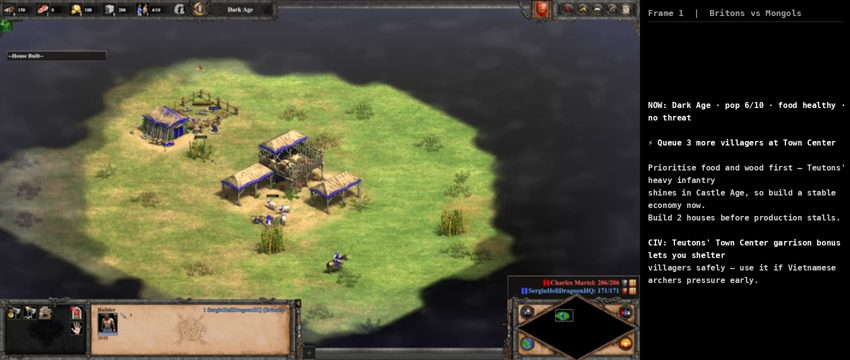

In [7]:
import textwrap
import numpy as np
import cv2
from PIL import Image, ImageDraw, ImageFont

# ── Panel geometry ────────────────────────────────────────────────────────────
PANEL_WIDTH   = 420    # fixed pixel width of the strategy panel
FONT_SIZE     = 19
PADDING       = 16     # pixels of margin inside the panel
LINE_SPACING  = 6      # extra px between lines

# ── Colours (RGB tuples) ──────────────────────────────────────────────────────
BG_COLOR      = (0,   0,   0)      # pure black panel
LABEL_COLOR   = (160, 160, 160)    # frame label — grey
HEADER_COLOR  = (255, 255, 255)    # section headers (NOW / ⚡ / CIV) — bright white
BODY_COLOR    = (210, 210, 210)    # body text — off-white
DIVIDER_COLOR = (60,  60,  60)     # subtle horizontal rule after label


def _load_font(size: int) -> ImageFont.FreeTypeFont | ImageFont.ImageFont:
    """Try to load a monospace TTF; fall back to PIL default."""
    for path in [
        "/usr/share/fonts/truetype/dejavu/DejaVuSansMono-Bold.ttf",
        "/usr/share/fonts/truetype/dejavu/DejaVuSansMono.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationMono-Regular.ttf",
        "/usr/share/fonts/truetype/freefont/FreeMono.ttf",
        "/usr/share/fonts/truetype/ubuntu/UbuntuMono-R.ttf",
    ]:
        if os.path.exists(path):
            return ImageFont.truetype(path, size)
    return ImageFont.load_default()


def _build_panel(H: int, strategy_text: str, frame_label: str) -> np.ndarray:
    """
    Render a standalone black strategy panel as an RGB numpy array of
    shape (H, PANEL_WIDTH, 3).  Text is vertically centred below the label.
    """
    panel_pil = Image.new("RGB", (PANEL_WIDTH, H), color=BG_COLOR)
    draw      = ImageDraw.Draw(panel_pil)
    font_lbl  = _load_font(FONT_SIZE - 2)
    font_body = _load_font(FONT_SIZE - 3)
    line_h    = FONT_SIZE + LINE_SPACING

    # ── Frame label at the top ────────────────────────────────────────────────
    y = PADDING
    if frame_label:
        draw.text((PADDING, y), frame_label, font=font_lbl, fill=LABEL_COLOR)
        y += line_h
        draw.line([(PADDING, y + 2), (PANEL_WIDTH - PADDING, y + 2)], fill=DIVIDER_COLOR, width=1)
        y += PADDING

    # ── Wrap body text ────────────────────────────────────────────────────────
    usable_w  = PANEL_WIDTH - 2 * PADDING
    char_w    = (FONT_SIZE - 3) * 0.56
    wrap_cols = max(10, int(usable_w / char_w))

    wrapped_lines = []   # list of (text, color)
    for raw in strategy_text.splitlines():
        if raw.strip() == "":
            wrapped_lines.append(("", BODY_COLOR))
            continue
        is_header = raw.lstrip().startswith(("NOW:", "⚡", "CIV:", "##", "**"))
        color     = HEADER_COLOR if is_header else BODY_COLOR
        for sub in textwrap.wrap(raw, width=wrap_cols) or [""]:
            wrapped_lines.append((sub, color))

    # ── Vertically centre the text block ─────────────────────────────────────
    block_h = len(wrapped_lines) * line_h
    label_bottom = y
    remaining    = H - label_bottom
    text_y       = label_bottom + max(0, (remaining - block_h) // 2)

    for text, color in wrapped_lines:
        if text_y + line_h > H:          # don't draw outside the panel
            break
        draw.text((PADDING, text_y), text, font=font_body, fill=color)
        text_y += line_h

    return np.array(panel_pil)           # RGB numpy array


def overlay_strategy(pil_img: Image.Image, strategy_text: str, frame_label: str = "") -> Image.Image:
    """
    Attach a separate black strategy panel to the RIGHT of the game frame
    using cv2.hconcat — the game image is never modified.

    Layout:
        ┌─────────────────────────────────────┬──────────────────┐
        │  game frame (untouched)             │  strategy panel  │
        │                                     │  [label]         │
        │                                     │  ─────────────── │
        │                                     │  NOW: …          │
        │                                     │  ⚡ priority     │
        │                                     │  recommendation  │
        │                                     │  CIV: …          │
        └─────────────────────────────────────┴──────────────────┘

    Returns a PIL Image.
    """
    frame_rgb = np.array(pil_img.convert("RGB"))        # H × W × 3  (RGB)
    H         = frame_rgb.shape[0]

    panel_rgb = _build_panel(H, strategy_text, frame_label)  # H × PANEL_WIDTH × 3

    # cv2.hconcat expects BGR arrays of identical height
    frame_bgr = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)
    panel_bgr = cv2.cvtColor(panel_rgb, cv2.COLOR_RGB2BGR)

    combined_bgr = cv2.hconcat([frame_bgr, panel_bgr])
    combined_rgb = cv2.cvtColor(combined_bgr, cv2.COLOR_BGR2RGB)

    return Image.fromarray(combined_rgb)


# ── Smoke-test on real frame ──────────────────────────────────────────────────
_test = Image.open(
    "/mnt/e/Personal/Samarth/repository/AOE-Agent/src/aoe2_agent/notebooks/output/frame_1.jpg"
)
_sample_text = (
    "NOW: Dark Age · pop 6/10 · food healthy · no threat\n"
    "\n"
    "⚡ Queue 3 more villagers at Town Center\n"
    "\n"
    "Prioritise food and wood first — Teutons' heavy infantry\n"
    "shines in Castle Age, so build a stable economy now.\n"
    "Build 2 houses before production stalls.\n"
    "\n"
    "CIV: Teutons' Town Center garrison bonus lets you shelter\n"
    "villagers safely — use it if Vietnamese archers pressure early."
)
_result = overlay_strategy(_test, _sample_text, f"Frame 1  |  {PLAYER_CIV} vs {OPPONENT_CIV}")
print(f"Game frame: {_test.size}  →  Combined: {_result.size}")
display(_result.resize((_result.width // 2, _result.height // 2)))

### Add Summarizer

In [ ]:
import re
from typing import Optional
from pydantic import BaseModel, Field
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_groq import ChatGroq

# ── Pydantic schema for the condensed overlay ─────────────────────────────────
class StrategySummary(BaseModel):
    """Compact strategy card shown on the game overlay."""
    situation: str = Field(
        description="One-line read of the current game state (age, key resources, threat)."
    )
    priority: str = Field(
        description="The single most important action to take right now."
    )
    recommendation: str = Field(
        description="2-3 sentences of actionable advice grounded in the current snapshot."
    )
    civ_strength: str = Field(
        description="1-2 sentences on how to leverage this civilization's unique strengths in the current situation."
    )

# ── Summarizer LLM (separate from Strategist — faster, creative) ─────────────
#_summarizer_llm = ChatOllama(model="gemma4:latest", temperature=1)
os.environ["GROQ_API_KEY"] = ''
_summarizer_llm = ChatGroq(model='llama-3.3-70b-versatile')


In [9]:
SUMMARY_SYSTEM_PROMPT = """\
You are a concise AoE2 coaching card writer.
Given a full strategy analysis, distil it into a tight overlay card that a player
can read at a glance during a live game.
Respond ONLY with valid JSON matching the StrategySummary schema — no markdown fences,
no extra keys, no explanation outside the JSON.

Schema:
{
  "situation":    "<one-line current state>",
  "priority":     "<single most important action>",
  "recommendation": "<2-3 sentences of grounded advice>",
  "civ_strength": "<1-2 sentences on civ-specific advantage to press>"
}
"""

def condense_strategy(full_text: str) -> str:
    """Summarise a full Strategist update into a compact overlay string.

    Uses llama3.1 with structured Pydantic output. Falls back to regex
    extraction if the LLM call or parse fails, so the overlay always has
    something to show.

    Returns a formatted multi-line string ready to pass to overlay_strategy().
    """
    import json

    # ── LLM summarisation ────────────────────────────────────────────────────
    try:
        messages = [
            SystemMessage(content=SUMMARY_SYSTEM_PROMPT),
            HumanMessage(content=f"Full strategy analysis:\n\n{full_text}"),
        ]
        response = _summarizer_llm.invoke(messages)
        raw = response.content.strip()

        # Strip accidental markdown fences
        if raw.startswith("```"):
            lines = raw.splitlines()
            raw = "\n".join(lines[1:-1] if lines[-1].strip() == "```" else lines[1:])

        data = json.loads(raw)
        summary = StrategySummary.model_validate(data)

        return (
            f"NOW: {summary.situation}\n"
            f"\n"
            f"⚡ {summary.priority}\n"
            f"\n"
            f"{summary.recommendation}\n"
            f"\n"
            f"CIV: {summary.civ_strength}"
        )

    except Exception as e:
        print(f"  [summarizer] LLM parse failed ({e}) — using regex fallback")

    # ── Regex fallback ────────────────────────────────────────────────────────
    priority = ""
    m = re.search(r"\*{0,2}Priority\*{0,2}\s*[:\-]\s*(.+)", full_text, re.IGNORECASE)
    if m:
        priority = m.group(1).strip().lstrip("*").rstrip("*").strip()

    actions = re.findall(r"^\s*(\d+)\.\s+(.+)", full_text, re.MULTILINE)
    action_lines = [f"{n}. {txt.strip()}" for n, txt in actions[:3]]

    parts = []
    if priority:
        parts.append(f"⚡ {priority}")
    if action_lines:
        if parts:
            parts.append("")
        parts.extend(action_lines)

    return "\n".join(parts) if parts else full_text[:300]


# ── Smoke-test ───────────────────────────────────────────────────────────────
_sample_full = """## Strategist Update — Dark Age

**Priority:** Queue 3 more villagers at Town Center

**Next actions:**
1. Assign idle villagers to food immediately
2. Build 2 houses to raise population cap
3. Scout the map with your starting scout
4. Research Double-Bit Axe (175W) at Lumber Camp
5. Advance to Feudal Age: 500F + 130W

**Rationale:** Teutons' strong tower defence and heavy infantry make a stable
economy into Castle Age the optimal opening. Prioritise food and wood first;
gold becomes critical only after Castle Age research begins.
"""

print("=== StrategySummary (LLM) ===")
result = condense_strategy(_sample_full)
print(result)
print(f"\nOriginal: {len(_sample_full)} chars  →  Condensed: {len(result)} chars")

=== StrategySummary (LLM) ===
NOW: Early Dark Age, initial villagers and scout

⚡ Queue 3 more villagers at Town Center

Focus on food and wood, assign idle villagers to food, and build houses to raise population cap. Scout the map with your starting scout to gather information. Research Double-Bit Axe to improve wood gathering efficiency.

CIV: Teutons' strong tower defence and heavy infantry provide a strong late-game advantage, making a stable economy into Castle Age a priority.

Original: 537 chars  →  Condensed: 456 chars


## Main Pipeline — Frame → VLM → Snapshot → Strategist → Annotated frame

For every saved frame:
1. Load the frame as PIL Image  
2. Call `gemma4:latest` (VLM) → `GameStateSnapshot`  
3. Feed snapshot to the Supervisor Strategist → strategy text  
4. Overlay the strategy text on the right side of the frame  
5. Save the annotated frame to `output_annotated/`  

`try / except` on every step so a bad frame just logs a warning and moves on.

In [ ]:
import glob
from collections import deque
from IPython.display import display, clear_output
from aoe2_agent.perception.loop import _parse_snapshot

# ── I/O directories ──────────────────────────────────────────────────────────
OUTPUT_ANNOTATED = os.path.join(
    "/mnt/e/Personal/Samarth/repository/AOE-Agent/src/aoe2_agent/notebooks",
    "output_annotated",
)
os.makedirs(OUTPUT_ANNOTATED, exist_ok=True)

# ── Gather frames — numeric sort so frame_2 comes before frame_10 ────────────
import re

def _numeric_key(p):
    m = re.search(r"(\d+)", os.path.basename(p))
    return int(m.group(1)) if m else 0

frame_paths = sorted(
    glob.glob(os.path.join(input_frames, "*.jpg"))
    + glob.glob(os.path.join(input_frames, "*.png")),
    key=_numeric_key,
)
print(f"Found {len(frame_paths)} frames in {input_frames}")

# ── Context carried between frames ───────────────────────────────────────────
history        = deque(maxlen=20)
last_strategy  = "Waiting for first analysis…"
results_log    = []           # (frame_name, snap, strategy_text, annotated_path)

# ── Per-frame pipeline ───────────────────────────────────────────────────────
for idx, frame_path in enumerate(frame_paths):
    frame_name = os.path.basename(frame_path)
    frame_label = f"Frame {idx}  |  {PLAYER_CIV} vs {OPPONENT_CIV}"
    print(f"\n{'─'*60}")
    print(f"[{idx+1}/{len(frame_paths)}] {frame_name}")

    # ── Step 1: load frame ────────────────────────────────────────────────────
    try:
        pil_img = Image.open(frame_path).convert("RGB")
    except Exception as e:
        print(f"  ⚠  Could not load frame — skipping. ({e})")
        continue

    # ── Step 2: VLM → GameStateSnapshot ──────────────────────────────────────
    snap = None
    try:
        raw_vlm = get_image_ocr(pil_img)
        snap    = _parse_snapshot(raw_vlm)
        if snap is None:
            raise ValueError("_parse_snapshot returned None")
        history.append(snap)
        print(f"  VLM → Age={snap.age}  Pop={snap.population}/{snap.pop_cap}"
              f"  Threat={snap.threat_level}  Food={snap.resources.get('food')}")
    except Exception as e:
        print(f"  ⚠  VLM / parse error — using last known snapshot. ({e})")
        snap = history[-1] if history else None

    # ── Step 3: Strategist → strategy text ───────────────────────────────────
    strategy_text = last_strategy # carry forward if Strategist fails
    if snap is not None:
        try:
            prompt  = _snapshot_to_prompt(snap, history, PLAYER_CIV, OPPONENT_CIV)
            result  = supervisor.invoke({"messages": [{"role": "user", "content": prompt}]})
            new_txt = _extract_last_content(result)
            if new_txt.strip():
                strategy_text = new_txt
                last_strategy = strategy_text
            print(f"  Strategist → {strategy_text[:80].replace(chr(10),' ')}…")
        except Exception as e:
            print(f"  ⚠  Strategist error — carrying forward last strategy. ({e})")
    else:
        print("  ⚠  No snapshot available — skipping Strategist call.")

    # ── Step 4: overlay + save ────────────────────────────────────────────────
    try:
        annotated    = overlay_strategy(pil_img, condense_strategy(strategy_text), frame_label)
        out_path     = os.path.join(OUTPUT_ANNOTATED, f"annotated_{frame_name}")
        annotated.save(out_path)
        results_log.append((frame_name, snap, strategy_text, out_path))
        print(f"  Saved → {out_path}")

        # Display inline in the notebook (last frame always shown; others every 5)
        if idx % 5 == 0 or idx == len(frame_paths) - 1:
            clear_output(wait=True)
            print(f"Preview — {frame_label}")
            display(annotated.resize((annotated.width // 2, annotated.height // 2)))
    except Exception as e:
        print(f"  ⚠  Overlay/save error — skipping. ({e})")
        continue

print(f"\n✅ Done. {len(results_log)}/{len(frame_paths)} frames annotated → {OUTPUT_ANNOTATED}")

## Results Summary — all frames at a glance

In [11]:
import math

print(f"{'Frame':<25} {'Age':<10} {'Pop':>6} {'Food':>6} {'Threat':<8}  Strategy (first 60 chars)")
print("─" * 110)
for frame_name, snap, strat, _ in results_log:
    age    = snap.age if snap else "—"
    pop    = f"{snap.population}/{snap.pop_cap}" if snap and snap.population else "—"
    food   = str(snap.resources.get("food", "—")) if snap else "—"
    threat = snap.threat_level if snap else "—"
    strat_preview = strat.replace("\n", " ")[:60]
    print(f"{frame_name:<25} {age:<10} {pop:>6} {food:>6} {threat:<8}  {strat_preview}…")

Frame                     Age           Pop   Food Threat    Strategy (first 60 chars)
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
frame_0.jpg               Dark          4/5    200 none      **Strategist Update — Dark Age**  **Priority:** Gather more …
frame_1.jpg               Dark         4/10    250 none      ## Strategist Update — Dark Age  **Priority:** Gather resour…
frame_2.jpg               Dark          6/6    250 none      Here is a detailed answer to the question based on the consu…
frame_3.jpg               Dark         8/55    230 none      ## Strategist Update — Dark Age  **Priority:** Gather wood a…
frame_4.jpg               Dark            —   None none      ## Strategist Update — Dark Age  **Priority:** Gather wood t…
frame_5.jpg               Dark         2/15    150 none      ## Strategist Update — Dark Age  **Priority:** Gather resour…
frame_6.jpg               Dark       24/None    250 low       Th

## Stitch Annotated Frames Back into a Video

Reassembles all annotated frames into `output_annotated.mp4` at the original FPS.

In [12]:
import cv2

annotated_paths = sorted(
    glob.glob(os.path.join(OUTPUT_ANNOTATED, "annotated_*.jpg"))
    + glob.glob(os.path.join(OUTPUT_ANNOTATED, "annotated_*.png"))
)

if not annotated_paths:
    print("No annotated frames found — run the pipeline cell first.")
else:
    # Determine output resolution from the first annotated frame
    sample = cv2.imread(annotated_paths[0])
    h, w   = sample.shape[:2]

    # Use the same FPS as the original video; fall back to 1 fps (one frame / 10s)
    try:
        cap_orig = cv2.VideoCapture(video_path)
        orig_fps = cap_orig.get(cv2.CAP_PROP_FPS) or 1.0
        # Frames were sampled every 10s, so the output video plays at 1 frame/s
        # so each strategy update is visible for 1 second
        out_fps = 1.0
        cap_orig.release()
    except Exception:
        out_fps = 1.0

    out_video_path = os.path.join(
        "/mnt/e/Personal/Samarth/repository/AOE-Agent",
        "output_annotated.mp4",
    )
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(out_video_path, fourcc, out_fps, (w, h))

    for apath in annotated_paths:
        try:
            frame = cv2.imread(apath)
            if frame is None:
                raise ValueError(f"cv2.imread returned None for {apath}")
            writer.write(frame)
        except Exception as e:
            print(f"  ⚠  Skipping {os.path.basename(apath)}: {e}")

    writer.release()
    print(f"✅ Video written → {out_video_path}  ({len(annotated_paths)} frames @ {out_fps} fps)")

✅ Video written → /mnt/e/Personal/Samarth/repository/AOE-Agent/output_annotated.mp4  (41 frames @ 1.0 fps)


## View a Single Annotated Frame

Use this cell to inspect any specific frame interactively.

In [ ]:
INSPECT_FRAME_IDX = 0   # ← change this to inspect any frame

if results_log and INSPECT_FRAME_IDX < len(results_log):
    frame_name, snap, strat, ann_path = results_log[INSPECT_FRAME_IDX]

    print(f"Frame:     {frame_name}")
    print(f"Civ:       {PLAYER_CIV} vs {OPPONENT_CIV}")
    if snap:
        print(f"Age:       {snap.age}")
        print(f"Pop:       {snap.population}/{snap.pop_cap}")
        print(f"Resources: {snap.resources}")
        print(f"Threat:    {snap.threat_level}")
        print(f"Idle vill: {snap.idle_villagers_visible}")
        print(f"Notes:     {snap.notes}")
    print("\n--- Strategy ---")
    print(strat)

    annotated_img = Image.open(ann_path)
    display(annotated_img.resize((annotated_img.width // 2, annotated_img.height // 2)))
else:
    print("Run the pipeline cell first, or adjust INSPECT_FRAME_IDX.")